In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
housing = pd.read_csv("./housing.csv")
housing = housing.drop("ocean_proximity", axis=1)
housing = housing.fillna(housing.median())

## Creating Income Categories
This code creates a new column 'income_cat' that categorizes the 'median_income' into five bins. Each bin represents a range of income levels, allowing us to stratify our sampling based on these categories.

In [5]:
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])

In [6]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [7]:
from sklearn.model_selection import StratifiedShuffleSplit

In [8]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in sss.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# saving the split data
strat_train_set.to_csv('train_set.csv', index=False)
strat_test_set.to_csv('test_set.csv', index=False)

print("✅ Datasets saved successfully!")

✅ Datasets saved successfully!


In [9]:
# removing income_cat column
for strat_sets in (strat_test_set, strat_train_set):
    strat_sets.drop("income_cat", axis=1, inplace=True)

In [10]:
# making a copy as it is a good practice 
copy_train_set = strat_train_set.copy()

In [11]:
copy_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0


<Figure size 1000x600 with 0 Axes>

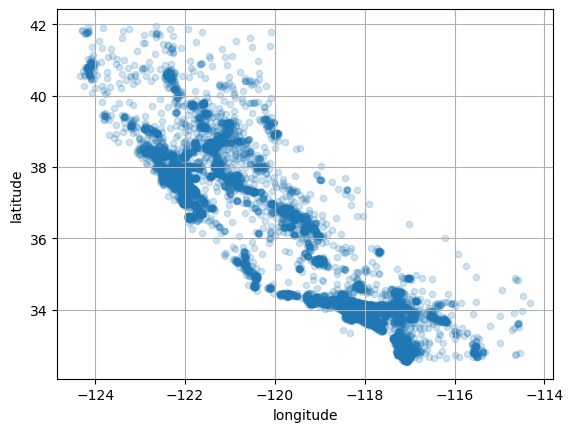

In [12]:
plt.figure(figsize=(10, 6))
# here alpha is used for lightness of the dots (see what we get after w remove alpha) 
copy_train_set.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

<Figure size 1000x600 with 0 Axes>

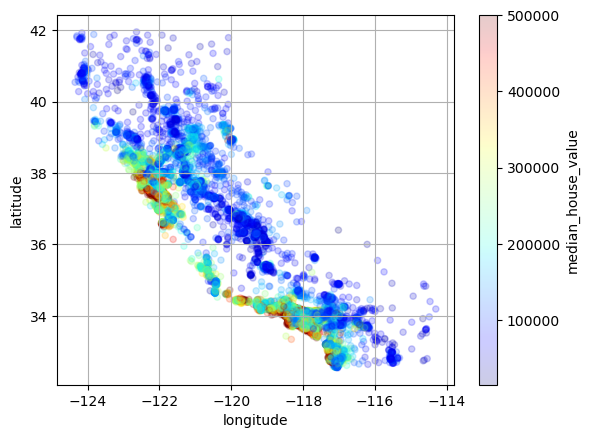

In [13]:
plt.figure(figsize=(10, 6))
# here alpha is used for lightness of the dots (see what we get after w remove alpha) 
copy_train_set.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2, cmap='jet', c='median_house_value')
plt.show()

In [14]:
corr_matrix = copy_train_set.corr()

In [16]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076335,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072213,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.323835,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.926347,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076335,-0.072213,-0.323835,0.926347,1.000000,0.871876,0.974541,-0.009419,0.047732
population,0.108071,-0.115290,-0.298737,0.855103,0.871876,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.974541,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009419,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047732,-0.026882,0.064590,0.687151,1.000000


In [17]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047732
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

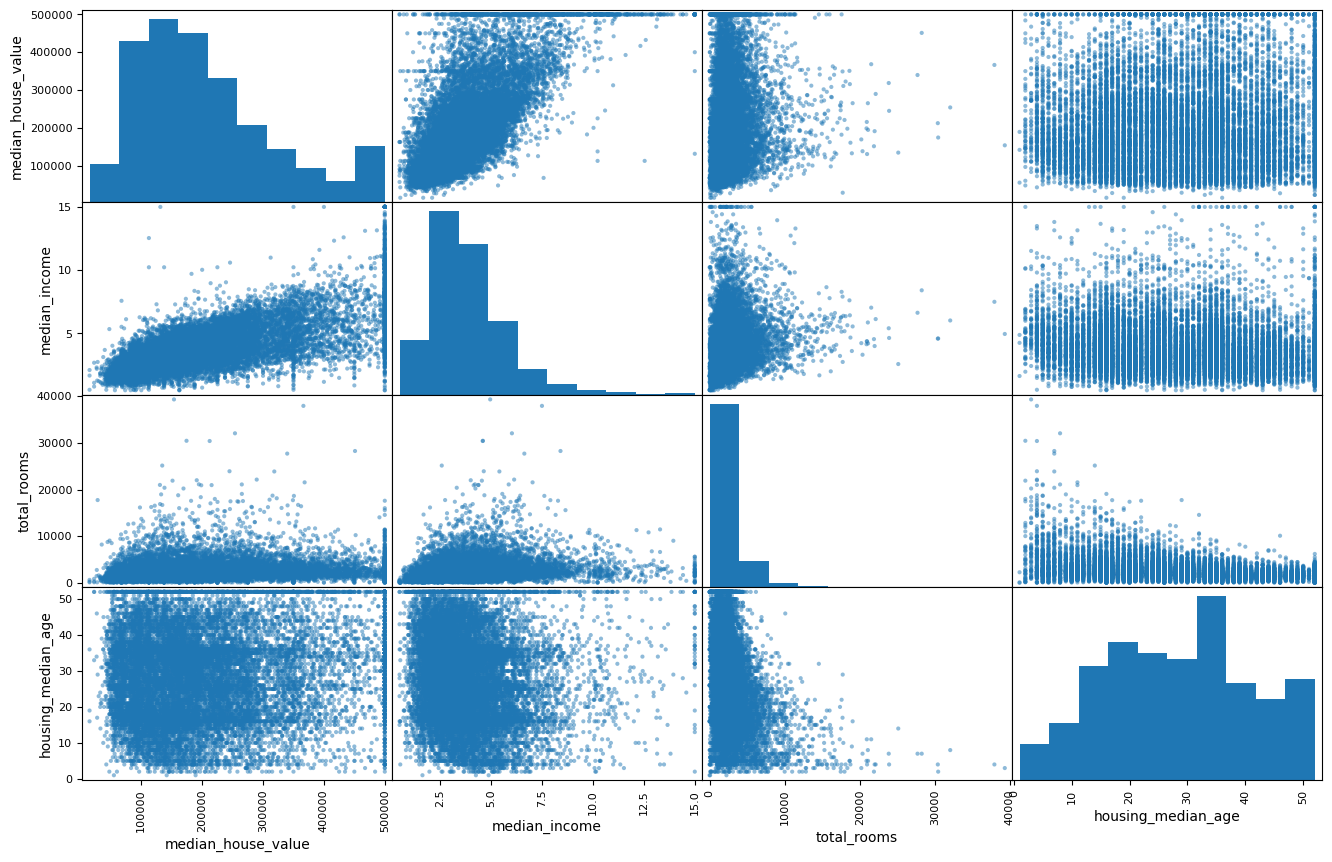

In [18]:
from pandas.plotting import scatter_matrix

# lets choose attributes
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(copy_train_set[attributes], figsize=(16, 10))
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

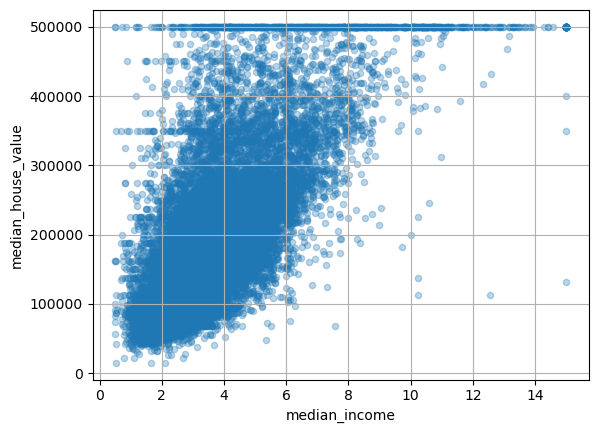

In [33]:
copy_train_set.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.3, grid=True)